Plotting System Metrics

1. Plotting TPS metrics...


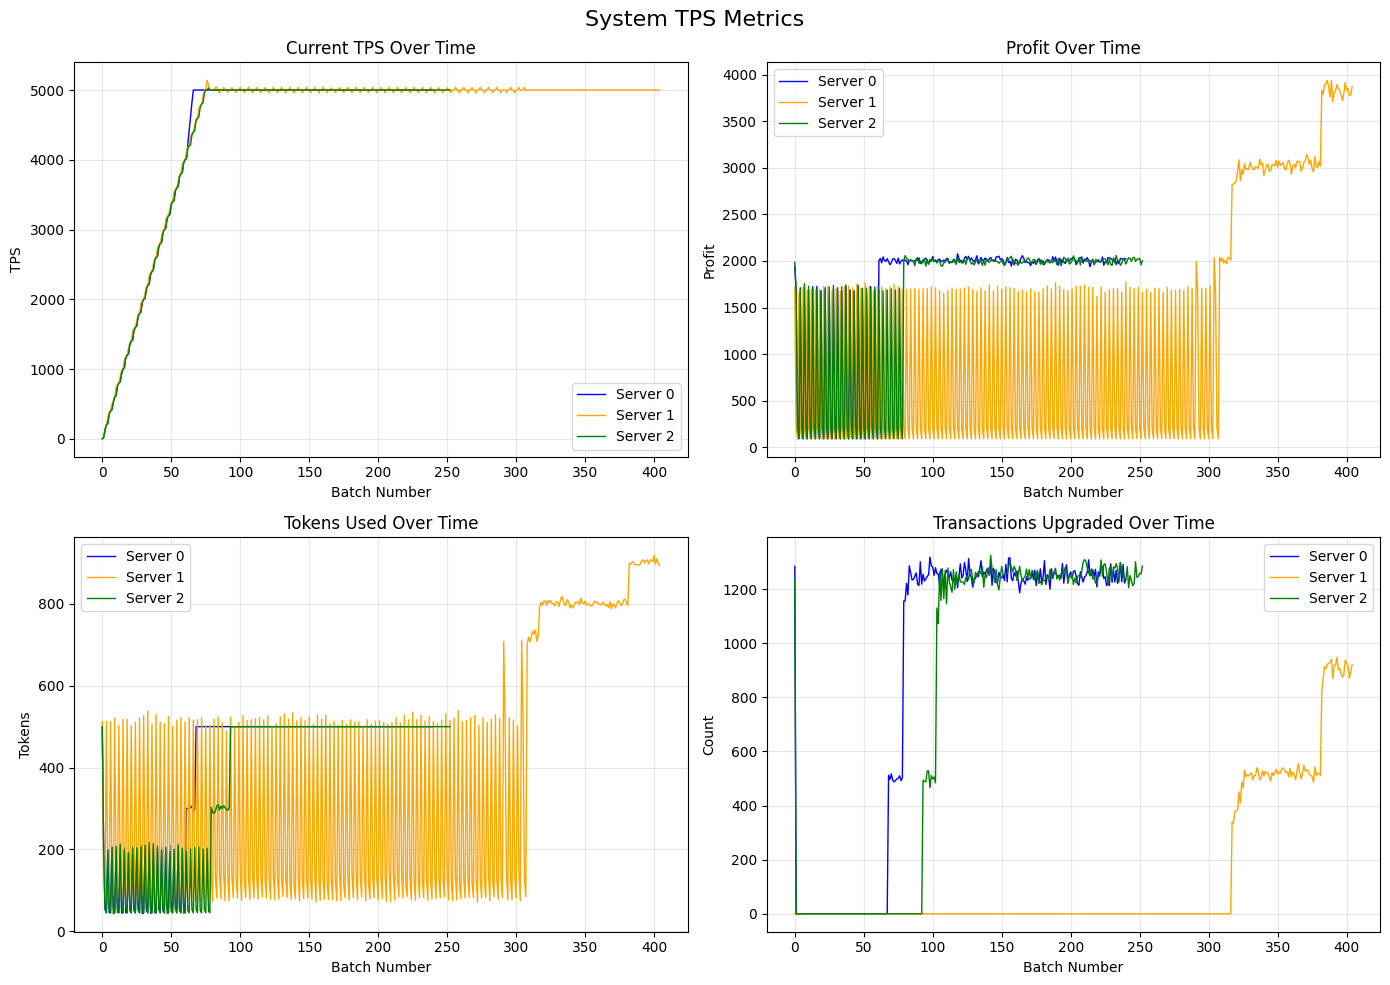


2. Plotting Incoming Transaction Rate...
File not found: ./incoming_transaction_rate_0.csv
File not found: ./incoming_transaction_rate_1.csv
File not found: ./incoming_transaction_rate_2.csv


/tmp/ipykernel_22800/3835299630.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].grid(True, alpha=0.3); axes[0].legend()
/tmp/ipykernel_22800/3835299630.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].grid(True, alpha=0.3); axes[1].legend()


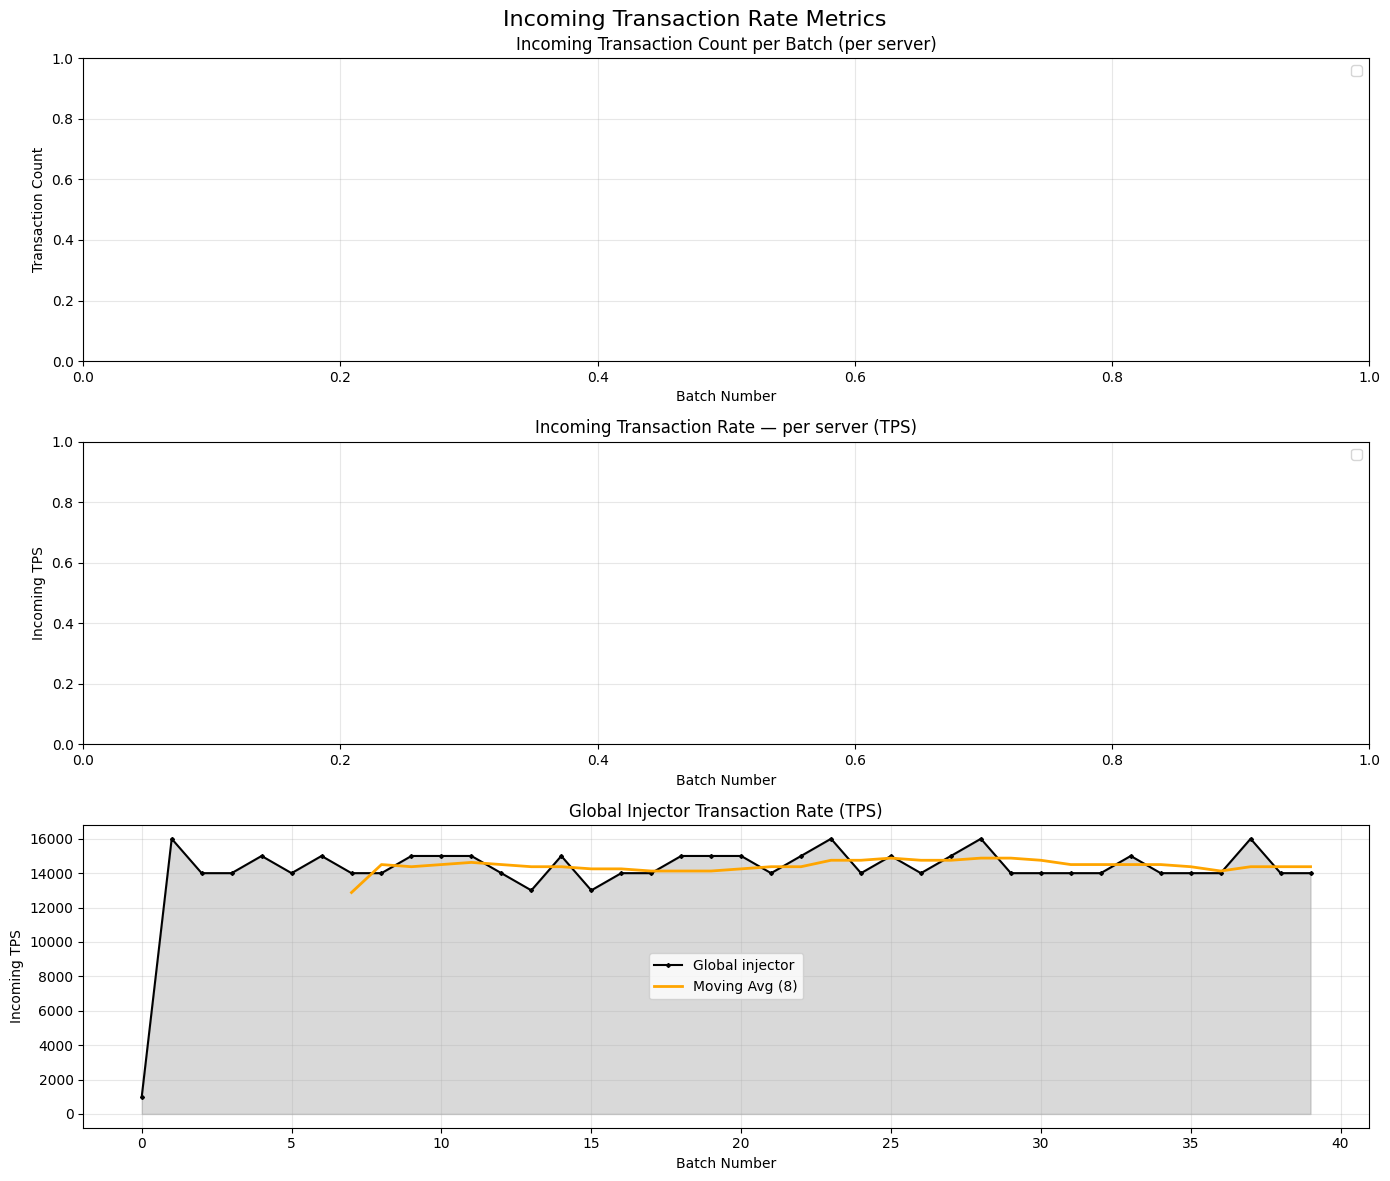


3. Plotting Backlog...


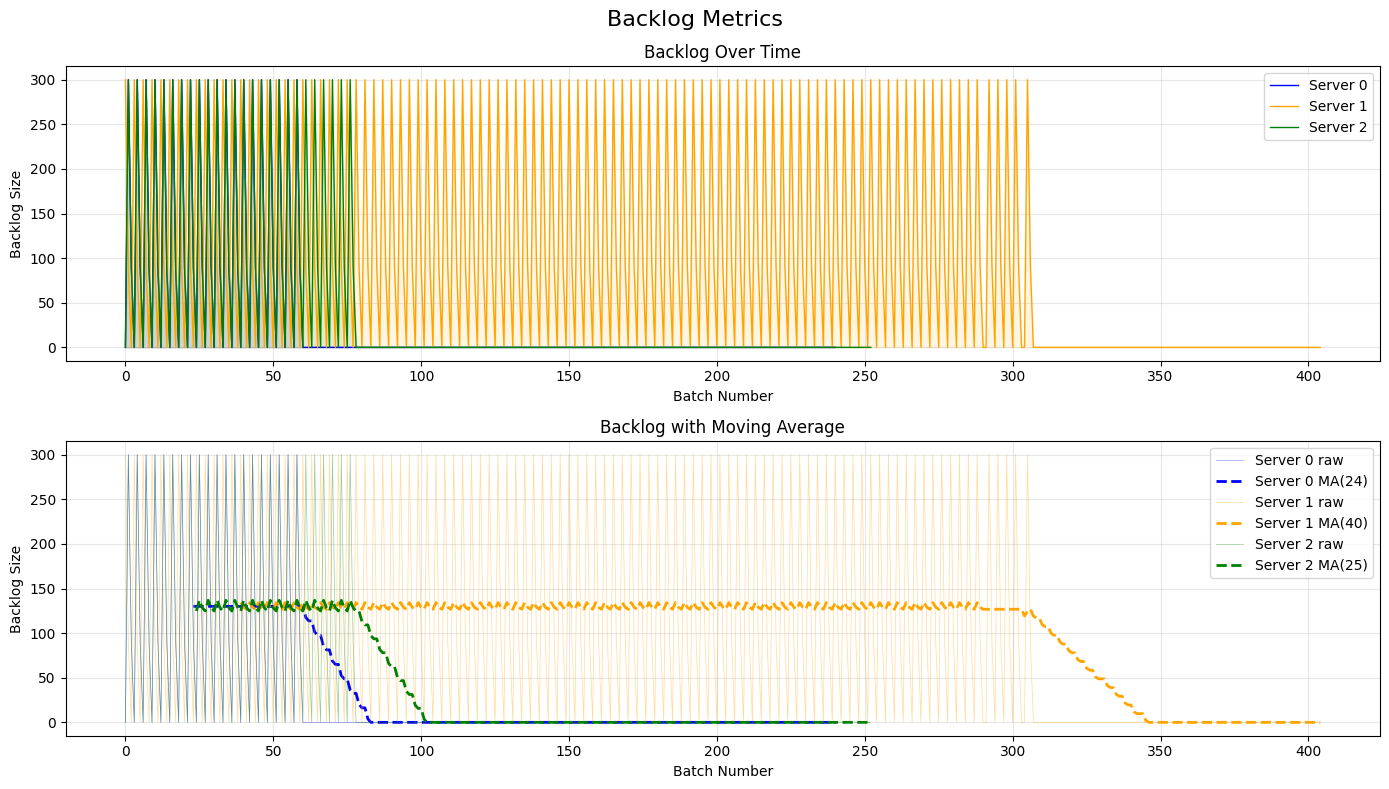


4. Plotting WriteConcern Frequency...


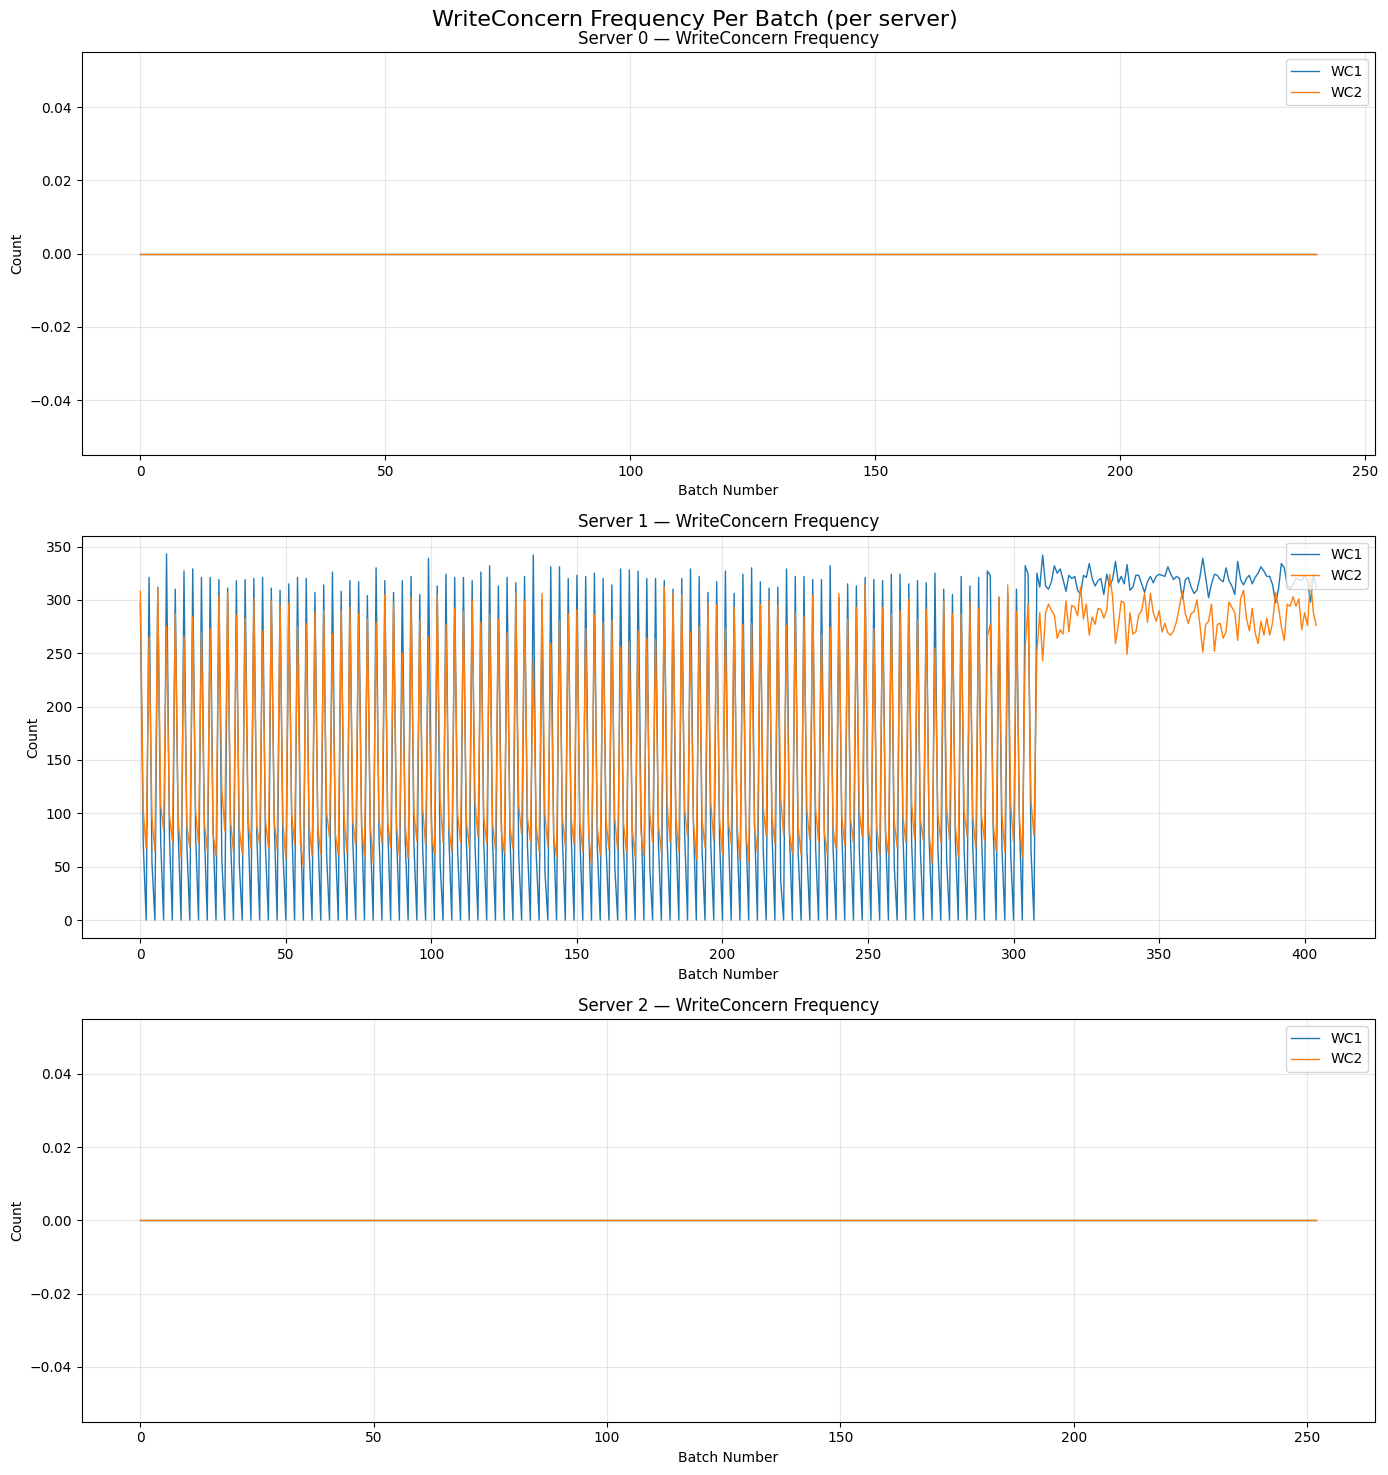


5. Plotting WriteConcern TPS...


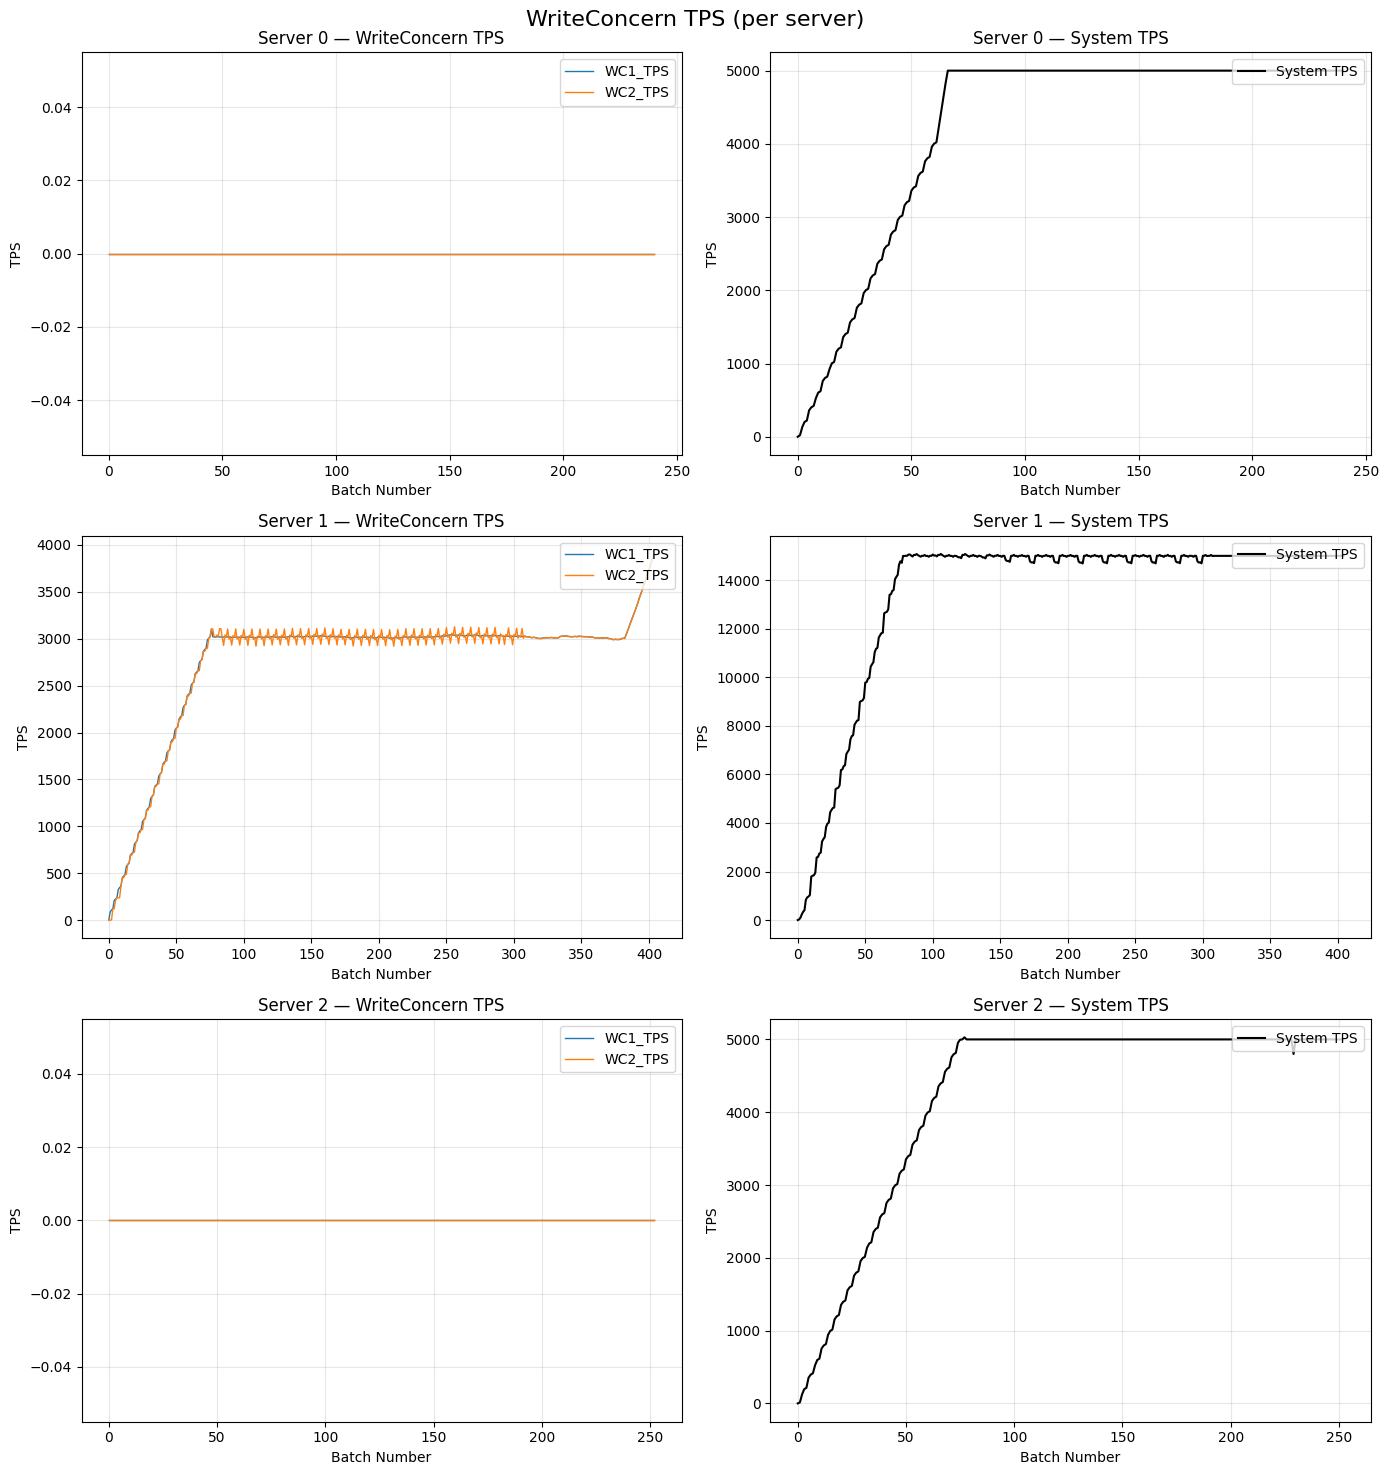


6. Plotting Final Batch Average TPS...
File not found: ./final_batch_avg_tps_log.csv

7. Plotting Combined Dashboard...


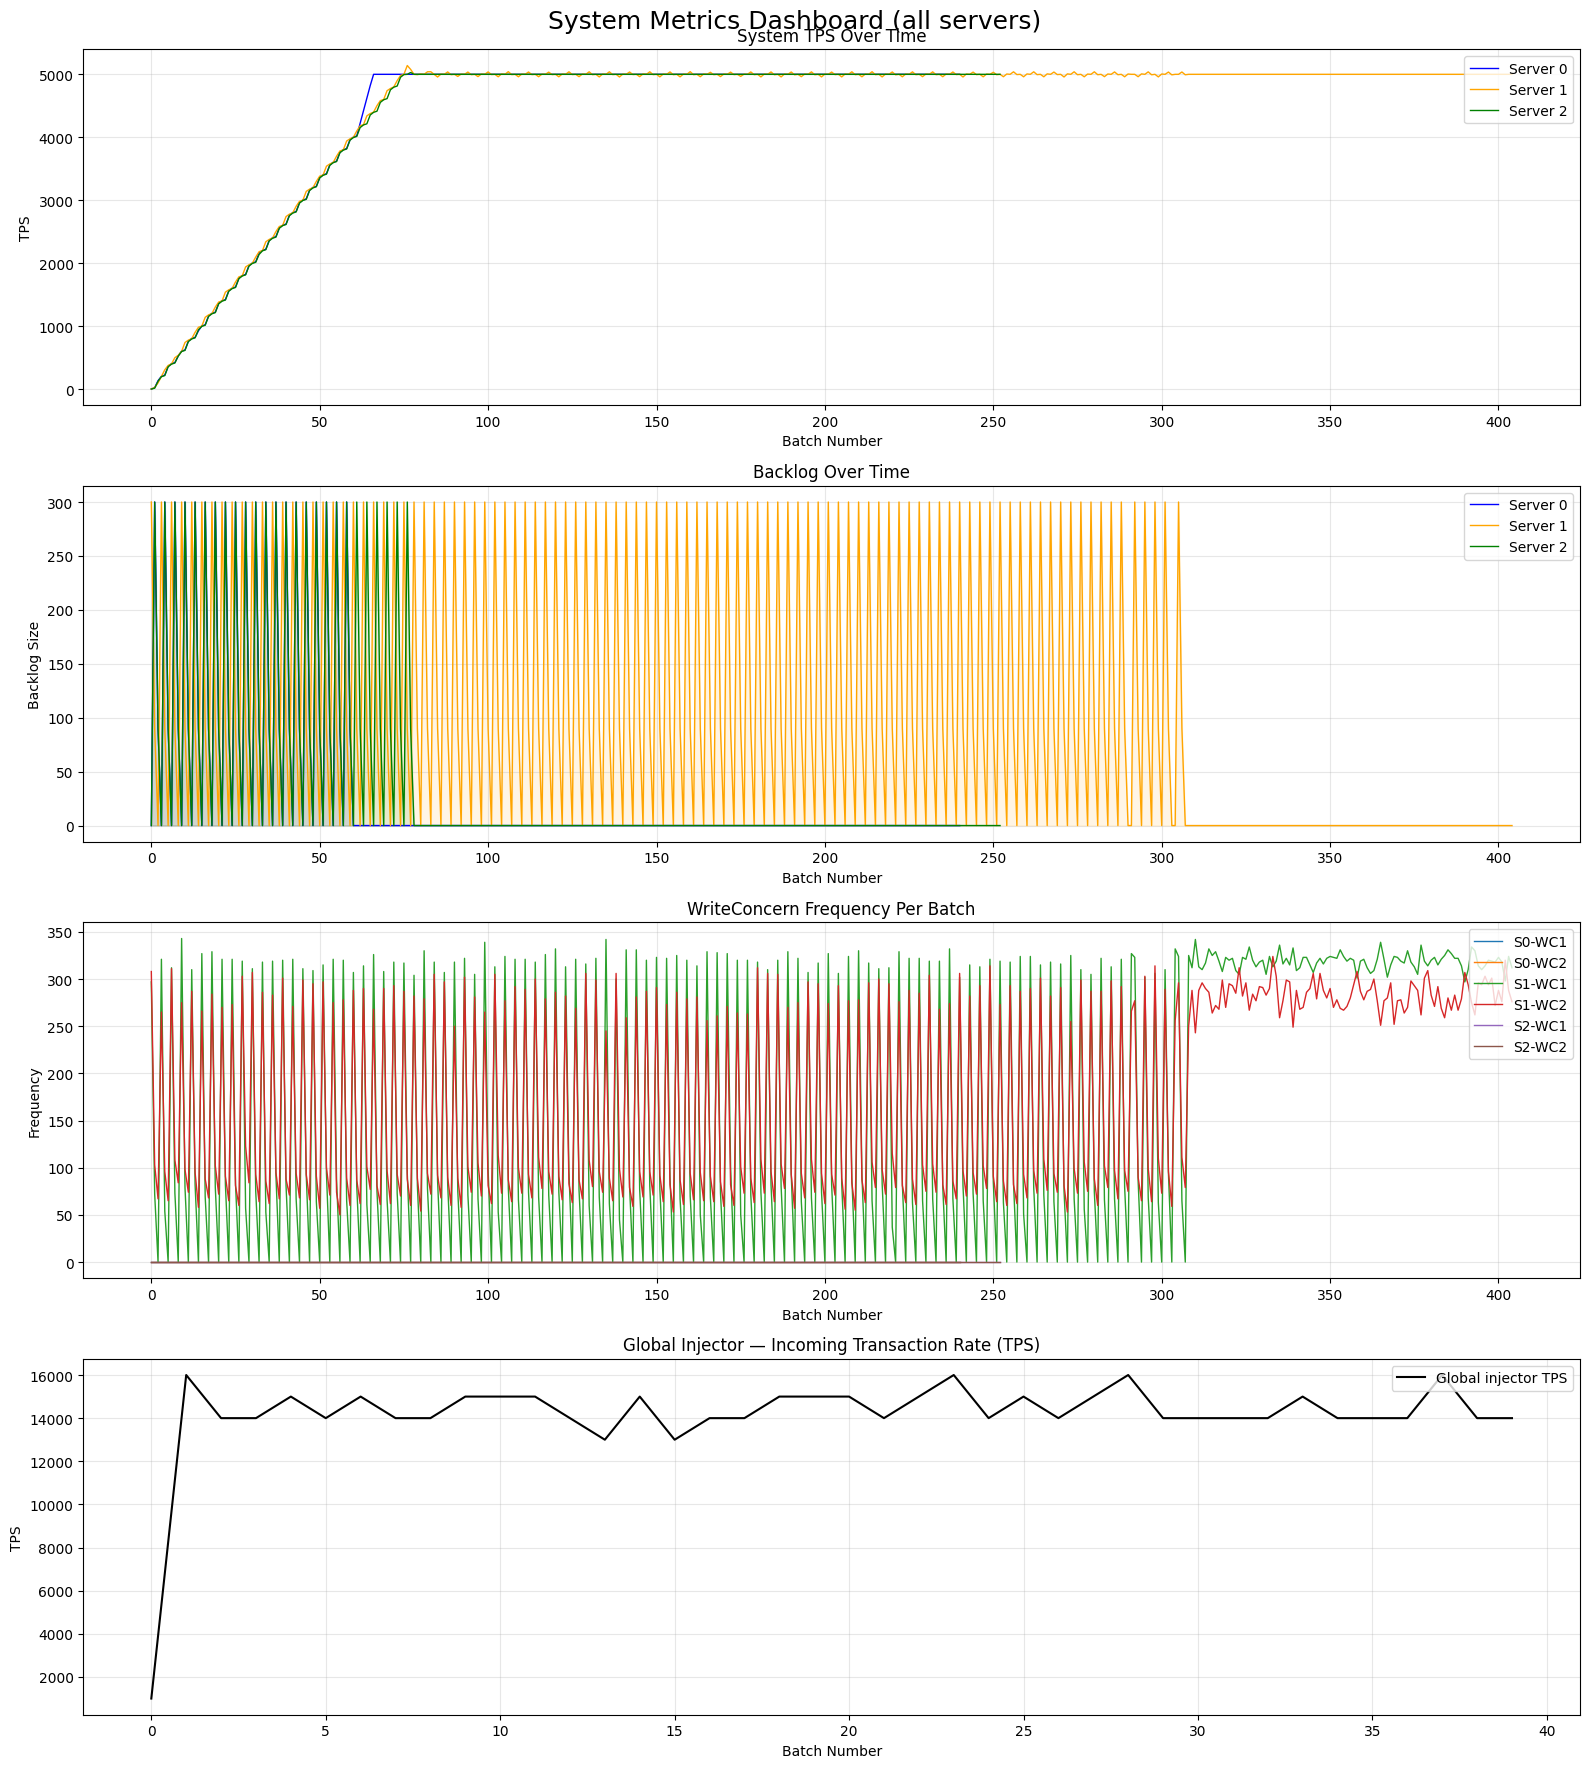


8. Plotting Stacked Area Chart...


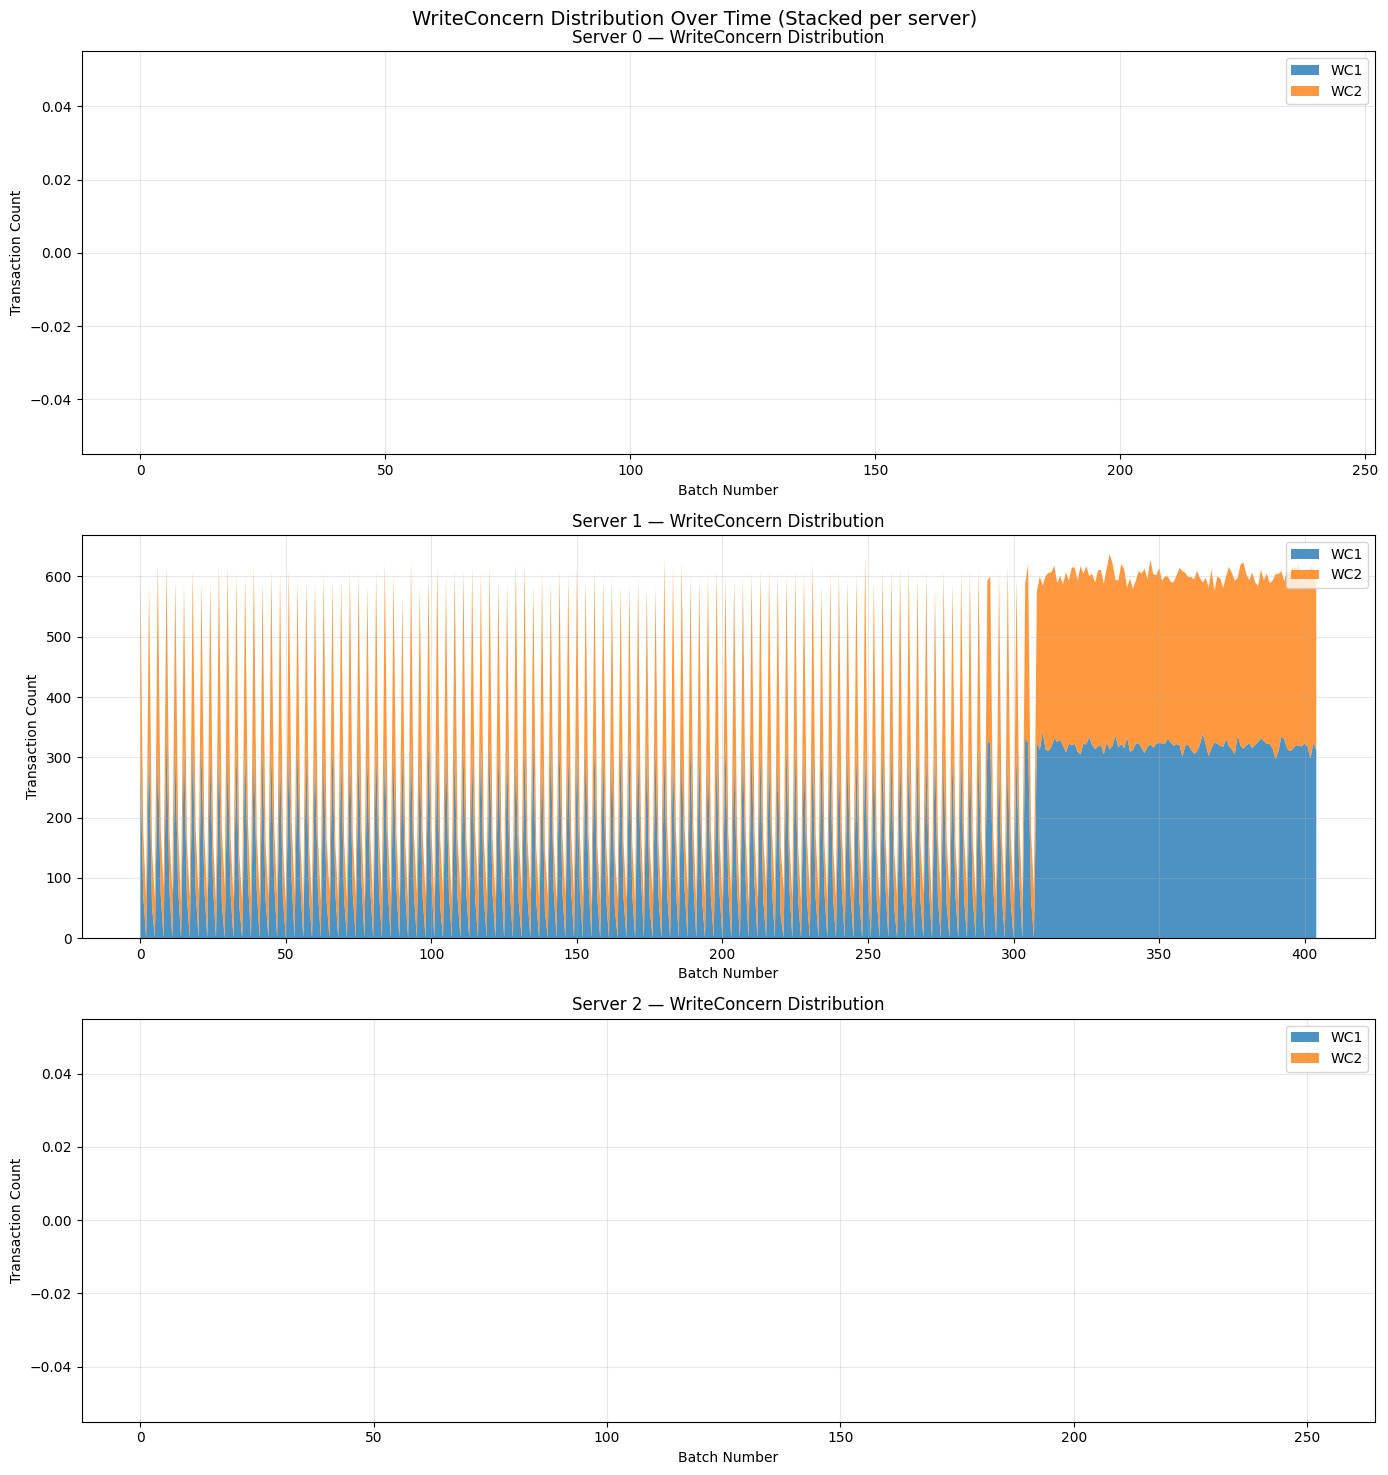


All plots generated successfully!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

# Server IDs — update to match the number of servers started in Servers.java
SERVER_IDS = [0, 1, 2]

COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_tps(server_ids=SERVER_IDS):
    """Plot system TPS metrics from tps_<id>.csv for each server"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0, 0].plot(df.index, df['CurrentTPS'], color=color, linewidth=1, label=label)
        axes[0, 1].plot(df.index, df['Profit'], color=color, linewidth=1, label=label)
        axes[1, 0].plot(df.index, df['TokensUsed'], color=color, linewidth=1, label=label)
        axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color=color, linewidth=1, label=label)

    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number'); axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend()

    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number'); axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend()

    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number'); axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend()

    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number'); axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def plot_incoming_transaction_rate(server_ids=SERVER_IDS):
    """Plot incoming transaction rate.
    - Top row:  per-server files  incoming_transaction_rate_<id>.csv  (received by each server)
    - Bottom row: global injector  incoming_transaction_rate_global.csv  (sent by Servers.java)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle('Incoming Transaction Rate Metrics', fontsize=16)

    # Per-server received rates
    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"incoming_transaction_rate_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        axes[0].plot(df.index, df['IncomingTransactionCount'], color=color, linewidth=1,
                     marker='o', markersize=2, label=f"Server {sid}")
        axes[1].plot(df.index, df['IncomingTPS'], color=color, linewidth=1,
                     marker='s', markersize=2, label=f"Server {sid}")

    axes[0].set_title('Incoming Transaction Count per Batch (per server)')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Transaction Count')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Incoming Transaction Rate — per server (TPS)')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Incoming TPS')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    # Global injector rate
    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[2].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5,
                     marker='D', markersize=2, label='Global injector')
        axes[2].fill_between(df_g.index, df_g['IncomingTPS'], alpha=0.15, color='black')
        window_size = min(20, len(df_g) // 5) if len(df_g) > 5 else 1
        if window_size > 1:
            df_g['TPS_MA'] = df_g['IncomingTPS'].rolling(window=window_size).mean()
            axes[2].plot(df_g.index, df_g['TPS_MA'], color='orange', linewidth=2,
                         label=f'Moving Avg ({window_size})')
    else:
        axes[2].text(0.5, 0.5, 'incoming_transaction_rate_global.csv not found',
                     ha='center', va='center', transform=axes[2].transAxes)

    axes[2].set_title('Global Injector Transaction Rate (TPS)')
    axes[2].set_xlabel('Batch Number'); axes[2].set_ylabel('Incoming TPS')
    axes[2].grid(True, alpha=0.3); axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_backlog(server_ids=SERVER_IDS):
    """Plot backlog metrics from backlog_<id>.csv"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)
        axes[0].fill_between(df.index, df['Backlog'], alpha=0.1, color=color)

        window_size = min(50, len(df) // 10) if len(df) > 10 else 1
        if window_size > 1:
            df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=0.5, alpha=0.4, label=f"Server {sid} raw")
            axes[1].plot(df.index, df['Backlog_MA'], color=color, linewidth=2,
                         linestyle='--', label=f"Server {sid} MA({window_size})")
        else:
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)

    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_writeconcern_frequency(server_ids=SERVER_IDS):
    """Plot writeConcern frequency from writeconcern_frequency_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 1,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern Frequency Per Batch (per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"writeconcern_frequency_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        wc_columns = [col for col in df.columns if col.startswith('WC')]
        for col in wc_columns:
            ax.plot(df.index, df[col], label=col, linewidth=1)
        ax.set_title(f"Server {sid} — WriteConcern Frequency")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_writeconcern_tps(server_ids=SERVER_IDS):
    """Plot writeConcern TPS from writeconcern_tps_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 2,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern TPS (per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"writeconcern_tps_{sid}.csv")
        ax_wc, ax_sys = axes_list[i][0], axes_list[i][1]
        if not os.path.exists(filepath):
            ax_wc.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
        for col in wc_tps_columns:
            ax_wc.plot(df.index, df[col], label=col, linewidth=1)
        ax_wc.set_title(f"Server {sid} — WriteConcern TPS")
        ax_wc.set_xlabel('Batch Number'); ax_wc.set_ylabel('TPS')
        ax_wc.legend(loc='upper right'); ax_wc.grid(True, alpha=0.3)
        if 'SystemTPS' in df.columns:
            ax_sys.plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        ax_sys.set_title(f"Server {sid} — System TPS")
        ax_sys.set_xlabel('Batch Number'); ax_sys.set_ylabel('TPS')
        ax_sys.legend(loc='upper right'); ax_sys.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_batch_avg_tps():
    """Plot batch average TPS from final_batch_avg_tps_log.csv (global file)"""
    filepath = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    df = pd.read_csv(filepath, header=None, names=['Timestamp', 'BatchAvgTPS'])
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Final Batch Average TPS Metrics', fontsize=16)
    axes[0].plot(df.index, df['BatchAvgTPS'], color='teal', linewidth=1)
    axes[0].set_title('Batch Average TPS')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('TPS')
    axes[0].grid(True, alpha=0.3)
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['BatchAvgTPS_MA'] = df['BatchAvgTPS'].rolling(window=window_size).mean()
        axes[0].plot(df.index, df['BatchAvgTPS_MA'], color='orange', linewidth=2,
                     label=f'Moving Avg ({window_size})')
        axes[0].legend()
    axes[1].hist(df['BatchAvgTPS'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_title('Distribution of Batch Average TPS')
    axes[1].set_xlabel('TPS'); axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    mean_tps = df['BatchAvgTPS'].mean()
    median_tps = df['BatchAvgTPS'].median()
    axes[1].axvline(mean_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tps:.0f}')
    axes[1].axvline(median_tps, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tps:.0f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print(f"\n📊 Batch Average TPS Statistics:")
    print(f"   Mean: {mean_tps:.2f}")
    print(f"   Median: {median_tps:.2f}")
    print(f"   Min: {df['BatchAvgTPS'].min():.2f}")
    print(f"   Max: {df['BatchAvgTPS'].max():.2f}")
    print(f"   Std Dev: {df['BatchAvgTPS'].std():.2f}")


def plot_combined_view(server_ids=SERVER_IDS):
    """Create a combined dashboard view overlaying all servers"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard (all servers)', fontsize=18)

    for i, sid in enumerate(server_ids):
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"

        tps_file = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if os.path.exists(tps_file):
            df_tps = pd.read_csv(tps_file)
            axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color=color, linewidth=1, label=label)

        backlog_file = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if os.path.exists(backlog_file):
            df_backlog = pd.read_csv(backlog_file)
            axes[1].plot(df_backlog.index, df_backlog['Backlog'], color=color, linewidth=1, label=label)
            axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.1, color=color)

        freq_file = os.path.join(CSV_DIR, f"writeconcern_frequency_{sid}.csv")
        if os.path.exists(freq_file):
            df_freq = pd.read_csv(freq_file)
            wc_columns = [col for col in df_freq.columns if col.startswith('WC')]
            for col in wc_columns:
                axes[2].plot(df_freq.index, df_freq[col], linewidth=1, label=f"S{sid}-{col}")

    axes[0].set_title('System TPS Over Time'); axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS'); axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Backlog Over Time'); axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size'); axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

    axes[2].set_title('WriteConcern Frequency Per Batch'); axes[2].set_xlabel('Batch Number')
    axes[2].set_ylabel('Frequency'); axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)

    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[3].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5, label='Global injector TPS')
        axes[3].set_title('Global Injector — Incoming Transaction Rate (TPS)')
        axes[3].set_xlabel('Batch Number'); axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_stacked_area_frequency(server_ids=SERVER_IDS):
    """Plot stacked area chart for writeConcern frequency distribution per server"""
    n = len(server_ids)
    fig, axes_list = plt.subplots(n, 1, figsize=(14, 5 * n), squeeze=False)
    fig.suptitle('WriteConcern Distribution Over Time (Stacked per server)', fontsize=14)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"writeconcern_frequency_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        wc_columns = [col for col in df.columns if col.startswith('WC')]
        ax.stackplot(df.index, [df[col] for col in wc_columns], labels=wc_columns, alpha=0.8)
        ax.set_title(f"Server {sid} — WriteConcern Distribution")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Transaction Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)

    print("\n1. Plotting TPS metrics...")
    plot_tps()

    print("\n2. Plotting Incoming Transaction Rate...")
    plot_incoming_transaction_rate()

    print("\n3. Plotting Backlog...")
    plot_backlog()

    print("\n4. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()

    print("\n5. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()

    print("\n6. Plotting Final Batch Average TPS...")
    plot_batch_avg_tps()

    print("\n7. Plotting Combined Dashboard...")
    plot_combined_view()

    print("\n8. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()

    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)


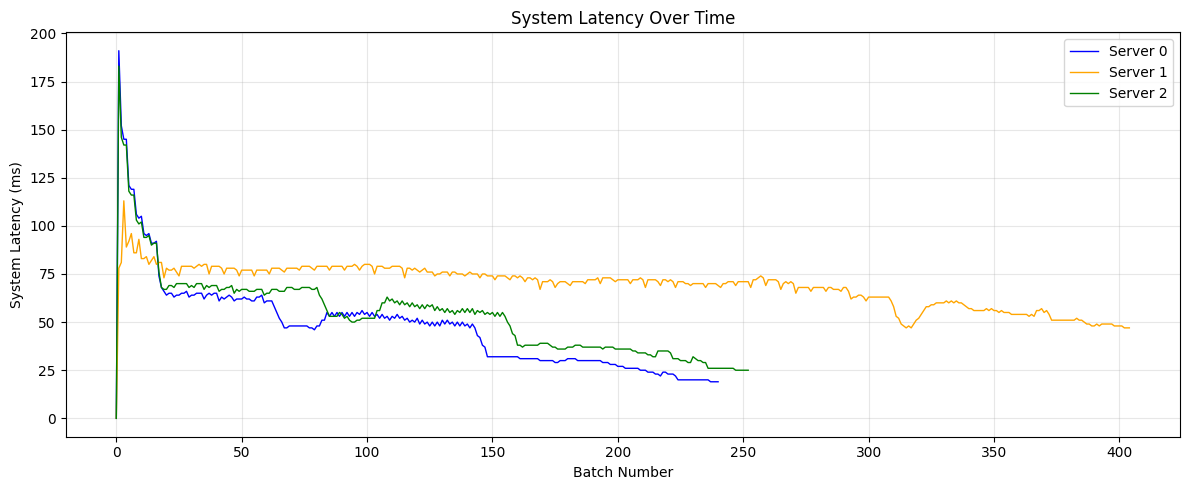

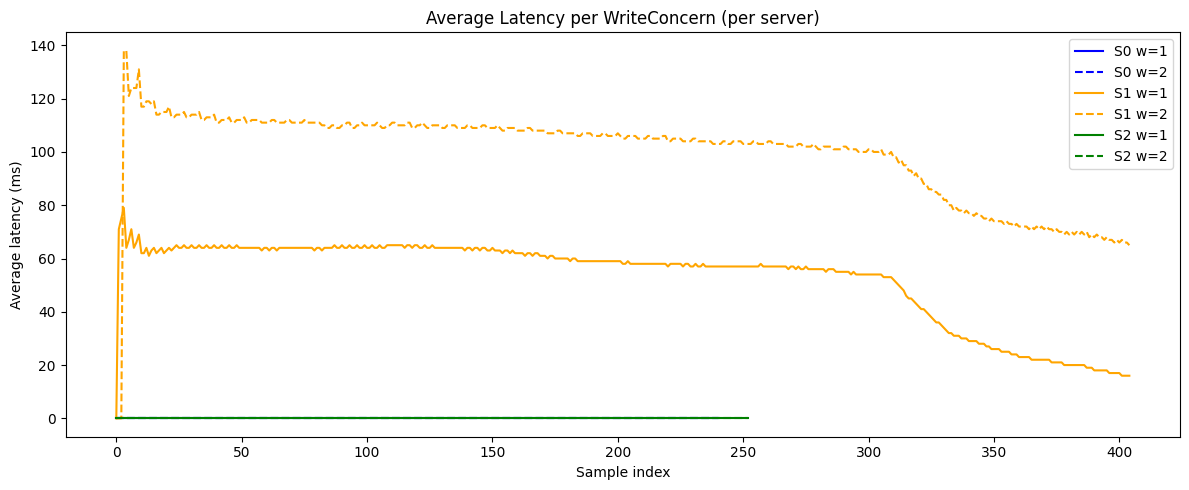

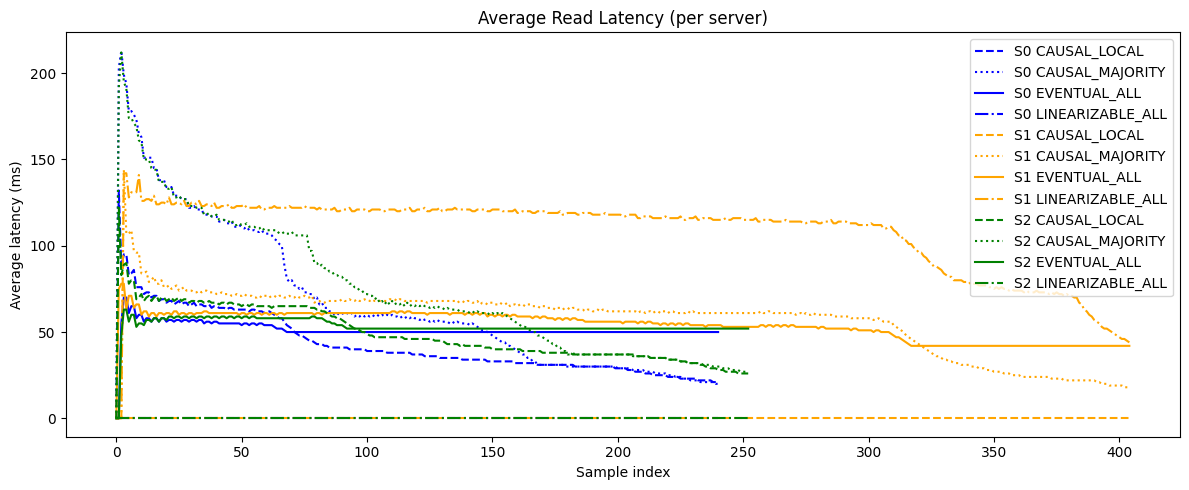

In [6]:
# Plot system latency and WC latencies per server
import pandas as pd
import matplotlib.pyplot as plt
import os

CSV_DIR = "."
SERVER_IDS = [0, 1, 2]
COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_system_latency(server_ids=SERVER_IDS):
    """Plot system latency from system_latency_<id>.csv for each server"""
    plt.figure(figsize=(12, 5))
    plt.title('System Latency Over Time')

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        plt.plot(df.index, df['SystemLatency'], linewidth=1,
                 color=COLORS[i % len(COLORS)], label=f"Server {sid}")

    plt.xlabel('Batch Number')
    plt.ylabel('System Latency (ms)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_wc_latencies(server_ids=SERVER_IDS):
    """Plot average latency per writeConcern from avg_latencies_<id>.csv"""
    plt.figure(figsize=(12, 5))
    plt.title('Average Latency per WriteConcern (per server)')

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"avg_latencies_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath, header=None, names=["wc", "avgLatency"])
        for wc, group in df.groupby("wc"):
            plt.plot(range(len(group)), group["avgLatency"],
                     color=COLORS[i % len(COLORS)],
                     linestyle=['-', '--', ':', '-.'][int(wc - 1) % 4],
                     label=f"S{sid} w={wc}")

    plt.xlabel("Sample index")
    plt.ylabel("Average latency (ms)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_read_latencies(server_ids=SERVER_IDS):
    """Plot average read latency from read_latencies_<id>.csv for each server.
    Supports both old format (ReadConcern) and new format (ReadLatencyKey).
    """
    plt.figure(figsize=(12, 5))
    plt.title('Average Read Latency (per server)')

    line_style_map = {
        'EVENTUAL_ALL': '-',
        'CAUSAL_LOCAL': '--',
        'CAUSAL_MAJORITY': ':',
        'LINEARIZABLE_ALL': '-.',
        'EVENTUAL': '-',
        'CAUSAL': '--',
        'LINEARIZABLE': ':'
    }

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"read_latencies_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)

        if 'ReadLatencyKey' in df.columns:
            group_col = 'ReadLatencyKey'
        elif 'ReadConcern' in df.columns:
            group_col = 'ReadConcern'
        else:
            print(f"Server {sid} — Missing ReadLatencyKey/ReadConcern column in {filepath}. Columns: {list(df.columns)}")
            continue

        if 'AvgLatencyMs' in df.columns:
            value_col = 'AvgLatencyMs'
        elif 'AvgLatency' in df.columns:
            value_col = 'AvgLatency'
        else:
            print(f"Server {sid} — Missing AvgLatencyMs/AvgLatency column in {filepath}. Columns: {list(df.columns)}")
            continue

        for key, group in df.groupby(group_col):
            key_str = str(key)
            linestyle = line_style_map.get(key_str, '-')
            plt.plot(range(len(group)), group[value_col],
                     color=COLORS[i % len(COLORS)],
                     linestyle=linestyle,
                     label=f"S{sid} {key_str}")

    plt.xlabel("Sample index")
    plt.ylabel("Average latency (ms)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_system_latency()
plot_wc_latencies()
plot_read_latencies()


In [ ]:
# Compute and print the average system latency for the first 900 samples per server
import pandas as pd
import os

CSV_DIR = "."
SERVER_IDS = [0, 1, 2]

for sid in SERVER_IDS:
    latency_file = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")
    if os.path.exists(latency_file):
        df_latency = pd.read_csv(latency_file)
        if 'SystemLatency' in df_latency.columns:
            first_n = df_latency.head(900)
            if not first_n.empty:
                avg_latency = first_n['SystemLatency'].mean()
                print(f"Server {sid} — Average System Latency (first 900 samples): {avg_latency:.2f} ms")
            else:
                print(f"Server {sid} — No data found in the first 900 samples.")
        else:
            print(f"Server {sid} — SystemLatency column not found in system_latency_{sid}.csv")
    else:
        print(f"Server {sid} — File not found: {latency_file}")


Average System Latency (first 100 samples): 93.20 ms


In [ ]:
# Plot backlog and EMA from backlog_samples_<id>.csv for each server
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_DIR = "."
SERVER_IDS = [0, 1, 2]
COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_backlog_and_ema_samples(server_ids=SERVER_IDS):
    """Read backlog_samples_<id>.csv for each server and plot Backlog + EMA vs sample index"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    fig.suptitle('Backlog and EMA (by sample index, per server)', fontsize=14)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"backlog_samples_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath} (expected columns: timestamp_ms,backlog,ema)")
            continue
        df = pd.read_csv(filepath)
        cols = {c.lower(): c for c in df.columns}
        if 'backlog' not in cols or 'ema' not in cols:
            print(f"Server {sid} — Required columns 'backlog' and 'ema' not found.")
            continue
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0].plot(df.index, df[cols['backlog']], color=color, linewidth=1, label=label)
        axes[1].plot(df.index, df[cols['ema']], color=color, linewidth=1, label=label)

    axes[0].set_title('Backlog (by sample index)')
    axes[0].set_ylabel('Backlog Size'); axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('EMA (by sample index)')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('EMA'); axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_backlog_and_ema_samples()


: 